# 03 – Preprocessing: Manejo de Valores Faltantes

**Proyecto:** Predicción de Subempleo por Insuficiencia de Horas — EPEN 2024  
**Dataset de entrada:** `epen_target_defined.csv` (universo analítico: trabajadores ocupados ≥ 14 años)

---

## Objetivo

Este notebook identifica, cuantifica y trata los valores faltantes en el dataset de trabajo, incluyendo:

- **Valores nulos reales** (`NaN`) presentes en el CSV cargado.
- **Códigos especiales de omisión** utilizados por la EPEN (ej. 99, 9999, 999999) que representan ausencia de información, no valores válidos.

El resultado es el dataset `epen_missing_handled.csv`, listo para las siguientes etapas del pipeline de preprocesamiento.

> **Restricciones:** Este notebook **no** realiza encoding categórico, balanceo de clases, train/test split ni entrenamiento de modelos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Cargar Dataset

Se intenta cargar `epen_target_defined.csv` como fuente principal. Si no existe, se utiliza `epen_filtered.csv` como fallback.

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR  = NOTEBOOK_DIR.parent

primary_path  = PROJECT_DIR / 'data' / 'processed' / 'epen_target_defined.csv'
fallback_path = PROJECT_DIR / 'data' / 'processed' / 'epen_filtered.csv'

if primary_path.exists():
    df = pd.read_csv(primary_path, encoding='utf-8-sig', low_memory=False)
    print(f"Archivo cargado: {primary_path.name}")
elif fallback_path.exists():
    df = pd.read_csv(fallback_path, encoding='utf-8-sig', low_memory=False)
    print(f"Archivo cargado (fallback): {fallback_path.name}")
else:
    raise FileNotFoundError(
        "No se encontró el dataset de entrada.\n"
        "Primero ejecuta uno de los siguientes notebooks:\n"
        "  - 02_data_understanding/target_definition.ipynb\n"
        "  - 03_preprocessing/variable_filtering.ipynb (si aplica)\n"
        f"Rutas buscadas:\n  {primary_path}\n  {fallback_path}"
    )

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas ({len(df.columns)}):")
print(list(df.columns))
df.head()

Archivo cargado: epen_target_defined.csv
Dimensiones: 24,054 filas × 136 columnas

Columnas (136):
['ANIO', 'MES', 'CONGLOMERADO', 'MUESTRA', 'SELVIV', 'HOGAR', 'REGION', 'LLAVE_PANEL', 'ESTRATO', 'C201', 'C203', 'C204', 'C205', 'C206', 'C207', 'C208', 'C300n', 'NROINF', 'C301_DIA', 'C301_MES', 'C301_ANIO', 'C303', 'C304', 'C305', 'C306_1', 'C306_2', 'C306_3', 'C306_4', 'C306_5', 'C306_6', 'C306_7', 'C306_8', 'C306_9', 'C306_10', 'C306_10A', 'C306_11', 'C306A', 'C308_COD', 'C309_COD', 'C310', 'C311', 'C312', 'C313', 'C317', 'C317A', 'C318_1', 'C318_2', 'C318_3', 'C318_4', 'C318_5', 'C318_6', 'C318_7', 'C318_T', 'C328_T', 'whoraT', 'C330', 'C331', 'C333', 'C334', 'P209H', 'C335', 'C338', 'C339_1', 'C341_T', 'C342', 'C344', 'C345_1', 'C347_T', 'C348', 'C350', 'C352', 'C353', 'C354', 'C355', 'C356', 'C357_I', 'C358', 'C359', 'SEGURO1', 'C361_1', 'C362_1', 'C361_2', 'C362_2', 'C361_3', 'C362_3', 'C361_4', 'C362_4', 'C361_5', 'C362_5', 'C361_6', 'C362_6', 'C361_7', 'C362_7', 'C361_8', 'C362

,ANIO,MES,CONGLOMERADO,MUESTRA,SELVIV,HOGAR,REGION,LLAVE_PANEL,ESTRATO,C201,C203,C204,C205,C206,C207,C208,C300n,NROINF,C301_DIA,C301_MES,C301_ANIO,C303,C304,C305,C306_1,...,C375_6,C376,C377,OCUP300,I339_1,D341_T,I342,D344,I345_1,I348,D347_T,D350,D351_T,INGTOT,INGTOTP,ingtrabw,RESIDENT,fa_ond24,fa_efm24,fa_amj24,fa_jas24,C208_num,OCUP300_num,P209H_num,target_subempleo_horas
0,2024,10,18117,2,61,1,1,202410181172006016.0000,1,1,1,1,2,,2,60,1,1,19,5,1964,1,,,,...,2,10,7,1,,,1367,,,,,,,1367,1367,1367,1,700.4007,NaN,NaN,NaN,60.0000,1.0000,2.0000,0
1,2024,10,18117,2,61,1,1,202410181172006016.0000,1,2,7,1,2,,2,49,2,2,30,11,1974,1,,,,...,2,10,7,1,,,1404,130,,,,,,1534,1534,1534,1,700.4007,NaN,NaN,NaN,49.0000,1.0000,1.0000,1
2,2024,10,1823302,1,59,1,1,20241018233021001728.0000,1,1,1,1,2,,1,52,1,2,14,9,1972,1,,,,...,2,10,7,1,,,1400,,,,,,,1400,1400,1400,1,896.4695,NaN,NaN,NaN,52.0000,1.0000,2.0000,0
3,2024,10,1823302,1,59,1,1,20241018233021001728.0000,1,2,2,1,2,,2,51,2,2,10,10,1972,1,,,,...,2,1,1,1,1516,,,,,,,,,1516,1516,1516,1,844.0361,NaN,NaN,NaN,51.0000,1.0000,2.0000,0
4,2024,10,1823302,1,60,1,1,20241018233021001728.0000,1,1,1,1,2,,2,43,1,1,25,4,1981,1,,,,...,2,10,1,1,1083,,,,,,,,,1083,1083,1083,1,1017.6463,NaN,NaN,NaN,43.0000,1.0000,2.0000,0


## 2. Validación Inicial

Antes de continuar, se verifica que el target exista, no tenga nulos y tenga la distribución esperada.

In [3]:
# Confirmar que target_subempleo_horas existe
assert 'target_subempleo_horas' in df.columns, \
    "ERROR: 'target_subempleo_horas' no encontrada. Ejecuta target_definition.ipynb primero."
print("✔  target_subempleo_horas presente.")

# Confirmar que el target no tiene nulos
nulos_target = df['target_subempleo_horas'].isnull().sum()
assert nulos_target == 0, f"ERROR: target_subempleo_horas tiene {nulos_target} valores nulos."
print("✔  target_subempleo_horas sin valores nulos.")

# Distribución del target
dist_target = df['target_subempleo_horas'].value_counts().sort_index()
dist_pct    = df['target_subempleo_horas'].value_counts(normalize=True).sort_index() * 100
etiquetas   = {0: 'No subempleado', 1: 'Subempleado'}

print(f"\n{'Distribución del target':─^50}")
for val, cnt in dist_target.items():
    label = etiquetas.get(val, str(val))
    print(f"  {val} ({label}): {cnt:>6,}  ({dist_pct[val]:.1f}%)")
print(f"  {'Total':─<20}: {len(df):>6,}")

✔  target_subempleo_horas presente.
✔  target_subempleo_horas sin valores nulos.

─────────────Distribución del target──────────────
  0 (No subempleado): 18,064  (75.1%)
  1 (Subempleado):  5,990  (24.9%)
  Total───────────────: 24,054


## 3. Identificar Valores Nulos Reales

Se calcula una tabla `missing_summary` con el conteo y porcentaje de nulos por columna, ordenada de mayor a menor. Solo se muestran las columnas con al menos un nulo.

In [4]:
missing_counts = df.isnull().sum()
missing_pct    = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'cantidad_nulos':   missing_counts,
    'porcentaje_nulos': missing_pct,
    'tipo_dato':        df.dtypes,
}).sort_values('porcentaje_nulos', ascending=False)

missing_con_nulos = missing_summary[missing_summary['cantidad_nulos'] > 0]

print(f"Columnas totales en el dataset:   {len(df.columns)}")
print(f"Columnas con al menos un nulo:    {len(missing_con_nulos)}")
print(f"Total de valores nulos en el CSV: {missing_counts.sum():,}")
print()
print(missing_con_nulos.to_string())

Columnas totales en el dataset:   136
Columnas con al menos un nulo:    4
Total de valores nulos en el CSV: 72,162

          cantidad_nulos  porcentaje_nulos tipo_dato
fa_ond24           18334           76.2200   float64
fa_jas24           18062           75.0900   float64
fa_amj24           17885           74.3500   float64
fa_efm24           17881           74.3400   float64


## 4. Identificar Códigos Especiales de Missing Values

La EPEN utiliza códigos numéricos que no quedan registrados como `NaN` en el CSV pero representan ausencia de información. Estos códigos deben identificarse y reemplazarse antes de imputar.

| Código | Significado | Variables típicas |
|--------|-------------|-------------------|
| `99` | No sabe / No responde / Missing en edad, horas, fechas | C208, C318_T, C328_T, whoraT, C331, C301_DIA, C301_MES |
| `9999` | Missing en año, código de ocupación/actividad, n° personas | C301_ANIO, C308_COD, C309_COD, C317A |
| `999999` | Missing en variables de ingresos (soles) | C339_1, C341_T, C342, C344, C345_1, C347_T, C348, C350, INGTOT, INGTOTP, INGTRABW |

> ⚠ **Importante:** Solo se reemplazarán estos códigos en las columnas donde corresponda según el diccionario EPEN.

In [5]:
# Verificar presencia de códigos especiales en el dataset actual
vars_check = {
    99:     ['C208', 'C318_T', 'C328_T', 'whoraT', 'C331', 'C301_DIA', 'C301_MES',
             'C318_1', 'C318_2', 'C318_3', 'C318_4', 'C318_5', 'C318_6', 'C318_7'],
    9999:   ['C301_ANIO', 'C308_COD', 'C309_COD', 'C317A'],
    999999: ['C339_1', 'C341_T', 'C342', 'C344', 'C345_1', 'C347_T', 'C348', 'C350',
             'INGTOT', 'INGTOTP', 'INGTRABW', 'I339_1', 'I342', 'I345_1', 'I348'],
}

print("Presencia de códigos especiales en el dataset:\n")
for codigo, cols in vars_check.items():
    total_code = 0
    hits = []
    for col in cols:
        if col in df.columns:
            n = (df[col] == codigo).sum()
            if n > 0:
                hits.append(f"    {col}: {n:,}")
                total_code += n
    print(f"  Código {codigo:>6} — {total_code:,} ocurrencias totales:")
    if hits:
        print('\n'.join(hits))
    else:
        print("    (ninguna en columnas revisadas)")
    print()

print("⚠  Solo se reemplazarán en las columnas especificadas en la sección siguiente.")

Presencia de códigos especiales en el dataset:

  Código     99 — 164 ocurrencias totales:
    C318_T: 1
    whoraT: 3
    C301_DIA: 78
    C301_MES: 82

  Código   9999 — 0 ocurrencias totales:
    (ninguna en columnas revisadas)

  Código 999999 — 0 ocurrencias totales:
    (ninguna en columnas revisadas)

⚠  Solo se reemplazarán en las columnas especificadas en la sección siguiente.


## 5. Crear Copia de Trabajo

Se guarda el conteo de nulos del CSV original y se crea `df_missing`, la copia de trabajo donde se aplicarán todos los tratamientos.

In [6]:
# Guardar estado de nulos ANTES de cualquier tratamiento
nulos_antes_serie = df.isnull().sum().copy()

# Crear copia de trabajo
df_missing = df.copy()

print(f"Copia de trabajo creada.")
print(f"Dimensiones: {df_missing.shape[0]:,} filas × {df_missing.shape[1]} columnas")
print(f"Nulos totales en dataset original: {nulos_antes_serie.sum():,}")

Copia de trabajo creada.
Dimensiones: 24,054 filas × 136 columnas
Nulos totales en dataset original: 72,162


## 6. Reemplazo Controlado de Códigos Especiales

Se reemplazan los códigos especiales por `np.nan` **únicamente en las columnas donde corresponde** según el diccionario EPEN.

In [7]:
# ─── a) Variables donde 99 representa missing ─────────────────────────────────
vars_99 = [
    'C208',
    'C318_1', 'C318_2', 'C318_3', 'C318_4', 'C318_5', 'C318_6', 'C318_7',
    'C318_T', 'C328_T', 'whoraT', 'C331',
    'C301_DIA', 'C301_MES',
]
print("── Código 99 ──────────────────────────────────────────────────────")
reemplazos_99 = 0
for col in vars_99:
    if col in df_missing.columns:
        n = (df_missing[col] == 99).sum()
        if n > 0:
            df_missing[col] = df_missing[col].replace(99, np.nan)
            print(f"  [99→NaN]  {col:<15}: {n:,} valores reemplazados")
            reemplazos_99 += n
print(f"  Subtotal: {reemplazos_99:,} reemplazos\n")

# ─── b) Variables donde 9999 representa missing ───────────────────────────────
vars_9999 = ['C301_ANIO', 'C308_COD', 'C309_COD', 'C317A']
print("── Código 9999 ────────────────────────────────────────────────────")
reemplazos_9999 = 0
for col in vars_9999:
    if col in df_missing.columns:
        n = (df_missing[col] == 9999).sum()
        if n > 0:
            df_missing[col] = df_missing[col].replace(9999, np.nan)
            print(f"  [9999→NaN]  {col:<15}: {n:,} valores reemplazados")
            reemplazos_9999 += n
print(f"  Subtotal: {reemplazos_9999:,} reemplazos\n")

# ─── c) Variables donde 999999 representa missing (ingresos brutos) ───────────
vars_999999 = [
    'C339_1', 'C341_T', 'C342', 'C344', 'C345_1',
    'C347_T', 'C348', 'C350',
]
print("── Código 999999 (ingresos brutos) ────────────────────────────────")
reemplazos_999999 = 0
for col in vars_999999:
    if col in df_missing.columns:
        n = (df_missing[col] == 999999).sum()
        if n > 0:
            df_missing[col] = df_missing[col].replace(999999, np.nan)
            print(f"  [999999→NaN]  {col:<15}: {n:,} valores reemplazados")
            reemplazos_999999 += n
print(f"  Subtotal: {reemplazos_999999:,} reemplazos\n")

# ─── d) Variables mensualizadas de ingresos ────────────────────────────────────
vars_ingresos_men = ['INGTOT', 'INGTOTP', 'INGTRABW', 'I339_1', 'I342', 'I345_1', 'I348']
print("── Código 999999 (ingresos mensualizados) ─────────────────────────")
reemplazos_ing = 0
for col in vars_ingresos_men:
    if col in df_missing.columns:
        n = (df_missing[col] == 999999).sum()
        if n > 0:
            df_missing[col] = df_missing[col].replace(999999, np.nan)
            print(f"  [999999→NaN]  {col:<15}: {n:,} valores reemplazados")
            reemplazos_ing += n
print(f"  Subtotal: {reemplazos_ing:,} reemplazos\n")

total_reemplazos = reemplazos_99 + reemplazos_9999 + reemplazos_999999 + reemplazos_ing
print(f"{'─'*60}")
print(f"Total de códigos especiales reemplazados: {total_reemplazos:,}")

── Código 99 ──────────────────────────────────────────────────────
  [99→NaN]  C318_T         : 1 valores reemplazados
  [99→NaN]  whoraT         : 3 valores reemplazados
  [99→NaN]  C301_DIA       : 78 valores reemplazados
  [99→NaN]  C301_MES       : 82 valores reemplazados
  Subtotal: 164 reemplazos

── Código 9999 ────────────────────────────────────────────────────
  Subtotal: 0 reemplazos

── Código 999999 (ingresos brutos) ────────────────────────────────
  Subtotal: 0 reemplazos

── Código 999999 (ingresos mensualizados) ─────────────────────────
  Subtotal: 0 reemplazos

────────────────────────────────────────────────────────────
Total de códigos especiales reemplazados: 164


## 7. Resumen Antes y Después del Reemplazo

Se construye una tabla comparativa para verificar el efecto del reemplazo de códigos especiales en el conteo de nulos.

In [8]:
nulos_despues_serie = df_missing.isnull().sum().copy()

comparacion = pd.DataFrame({
    'nulos_antes':   nulos_antes_serie,
    'nulos_despues': nulos_despues_serie,
}).assign(diferencia=lambda x: x['nulos_despues'] - x['nulos_antes'])

cambios = comparacion[comparacion['diferencia'] != 0].sort_values('diferencia', ascending=False)

print(f"Variables con cambios por reemplazo de códigos especiales: {len(cambios)}\n")
if len(cambios) > 0:
    print(cambios.to_string())
else:
    print("No se detectaron códigos especiales en las variables revisadas.")

print(f"\n{'─'*55}")
print(f"Nulos ANTES  (CSV original):     {nulos_antes_serie.sum():>10,}")
print(f"Nulos DESPUÉS (tras reemplazo):  {nulos_despues_serie.sum():>10,}")
print(f"Diferencia:                      {int((nulos_despues_serie - nulos_antes_serie).sum()):>+10,}")

Variables con cambios por reemplazo de códigos especiales: 4

          nulos_antes  nulos_despues  diferencia
C301_MES            0             82          82
C301_DIA            0             78          78
whoraT              0              3           3
C318_T              0              1           1

───────────────────────────────────────────────────────
Nulos ANTES  (CSV original):         72,162
Nulos DESPUÉS (tras reemplazo):      72,326
Diferencia:                            +164


## 8. Análisis de Nulos Posterior al Reemplazo

Se recalcula el porcentaje de nulos sobre el dataset de trabajo `df_missing` ya tratado y se visualiza el top 20 de variables con mayor porcentaje de faltantes.

Columnas con nulos tras reemplazo de códigos: 8
Total de nulos restantes:                     72,326

          cantidad_nulos  porcentaje_nulos
fa_ond24           18334           76.2200
fa_jas24           18062           75.0900
fa_amj24           17885           74.3500
fa_efm24           17881           74.3400
C301_MES              82            0.3400
C301_DIA              78            0.3200
whoraT                 3            0.0100
C318_T                 1            0.0000


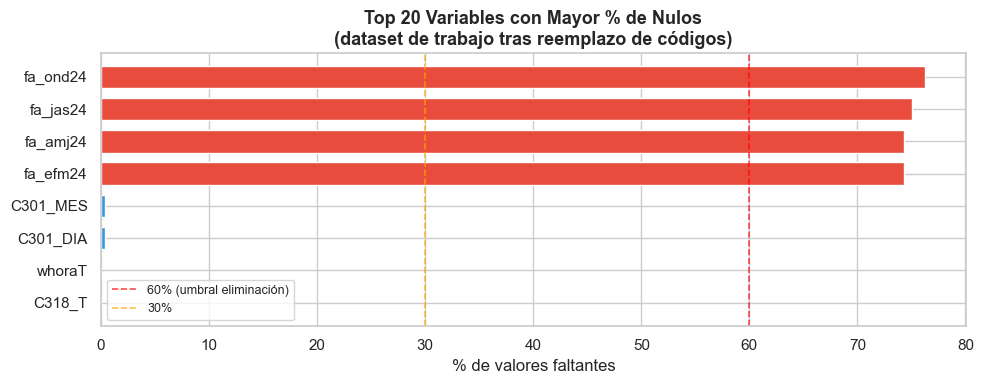

In [9]:
missing_post_counts = df_missing.isnull().sum()
missing_post_pct    = (df_missing.isnull().mean() * 100).round(2)

missing_post = pd.DataFrame({
    'cantidad_nulos':   missing_post_counts,
    'porcentaje_nulos': missing_post_pct,
}).sort_values('porcentaje_nulos', ascending=False)

missing_post_nulos = missing_post[missing_post['cantidad_nulos'] > 0]

print(f"Columnas con nulos tras reemplazo de códigos: {len(missing_post_nulos)}")
print(f"Total de nulos restantes:                     {missing_post_counts.sum():,}\n")
print(missing_post_nulos.head(30).to_string())

# ─── Gráfico: top 20 variables con mayor % de nulos ──────────────────────────
top20 = missing_post_nulos.head(20)
if len(top20) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(top20) * 0.45)))
    colors = [
        '#e74c3c' if p > 60 else '#e67e22' if p > 30 else '#3498db'
        for p in top20['porcentaje_nulos']
    ]
    ax.barh(
        top20.index[::-1],
        top20['porcentaje_nulos'][::-1],
        color=colors[::-1],
        edgecolor='white',
        height=0.7,
    )
    ax.axvline(x=60, color='red',    linestyle='--', alpha=0.7, linewidth=1.2, label='60% (umbral eliminación)')
    ax.axvline(x=30, color='orange', linestyle='--', alpha=0.7, linewidth=1.2, label='30%')
    ax.set_xlabel('% de valores faltantes', fontsize=12)
    ax.set_title(
        'Top 20 Variables con Mayor % de Nulos\n(dataset de trabajo tras reemplazo de códigos)',
        fontsize=13, fontweight='bold',
    )
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas con valores faltantes en el dataset de trabajo.")

## 9. Estrategia de Tratamiento de Nulos

Se define la estrategia de imputación según el tipo y porcentaje de nulos de cada variable.

| Situación | Estrategia aplicada |
|---|---|
| > 60% de nulos | Evaluar eliminación de la variable (salvo importancia conceptual) |
| Variables numéricas — nulos moderados | Imputar con **mediana** |
| Variables categóricas — nulos moderados | Imputar con **moda** |
| Variables categóricas — nulos altos (> 60%) | Crear categoría `−1` como "No informado" |
| Variables de ingresos | Imputar con mediana (missing = no respuesta, no ausencia real) |
| Variables de horas trabajadas | Imputar con mediana (universo = trabajadores ocupados) |
| Variables sensibles (etnicidad, discapacidad, salud) | Preferir `"No informado"` en lugar de imputación agresiva |

**Restricciones del notebook:**
- El target `target_subempleo_horas` **no se imputa**.
- Las variables de leakage `P209H`, `C333` y `C334` **no se usan** para imputar otras variables.
- No se realiza encoding, balanceo ni modelado en este notebook.

## 10. Crear Indicadores de Missingness

Antes de imputar, se crean variables binarias (`*_missing_flag`) que registran si el valor original era faltante (1 = era nulo, 0 = tenía valor). Esto es especialmente relevante para ingresos y horas, donde la ausencia del dato puede tener valor predictivo.

In [10]:
# Variables candidatas para flags (ingresos y horas)
vars_para_flag = [
    'INGTOT', 'INGTOTP', 'INGTRABW',
    'I339_1', 'I342', 'I345_1', 'I348',
    'whoraT', 'C318_T', 'C328_T', 'C331',
]

flags_creados = []
for col in vars_para_flag:
    if col not in df_missing.columns:
        continue
    # Usar estado ACTUAL de df_missing (después de reemplazar códigos especiales, antes de imputar)
    nulos_actuales = df_missing[col].isnull().sum()
    if nulos_actuales > 0:
        flag_col = f"{col}_missing_flag"
        df_missing[flag_col] = df_missing[col].isnull().astype(int)
        pct = nulos_actuales / len(df_missing) * 100
        flags_creados.append({
            'variable_original': col,
            'flag_creado':       flag_col,
            'casos_missing':     nulos_actuales,
            'pct_missing':       round(pct, 2),
        })
        print(f"  Flag creado: {flag_col:<30} ({nulos_actuales:,} casos, {pct:.2f}%)")

print(f"\nTotal de flags de missingness creados: {len(flags_creados)}")
if flags_creados:
    print()
    print(pd.DataFrame(flags_creados).to_string(index=False))

  Flag creado: whoraT_missing_flag            (3 casos, 0.01%)
  Flag creado: C318_T_missing_flag            (1 casos, 0.00%)

Total de flags de missingness creados: 2

variable_original         flag_creado  casos_missing  pct_missing
           whoraT whoraT_missing_flag              3       0.0100
           C318_T C318_T_missing_flag              1       0.0000


## 11. Aplicar Imputación Simple

Se aplica imputación básica por tipo de variable, respetando las restricciones establecidas (no imputar target ni variables de leakage).

In [11]:
# Variables que NO deben imputarse
LEAKAGE_VARS = {'P209H', 'C333', 'C334', 'target_subempleo_horas'}

# Umbral: si % nulos > 60%, no imputar automáticamente
UMBRAL_ALTO = 60.0

# ─── Candidatos numéricos → mediana ──────────────────────────────────────────
numeric_candidates = [
    'C208', 'C318_T', 'C328_T', 'whoraT', 'C331',
    'INGTOT', 'INGTOTP', 'INGTRABW',
    'I339_1', 'I342', 'I345_1', 'I348',
]

# ─── Candidatos categóricos → moda o "No informado" (-1) ─────────────────────
categorical_candidates = [
    'C203', 'C207', 'C310', 'C311', 'C312', 'C313',
    'C317', 'C335', 'SEGURO1',
    'C361_1', 'C361_5', 'C364_1', 'C364_2',
    'C366', 'C376', 'C377',
]

# ─── Candidatos binarios 1/2 → moda ──────────────────────────────────────────
binary_candidates = [
    'C361_1', 'C361_5', 'C364_1', 'C364_2',
    'C375_1', 'C375_2', 'C375_3', 'C375_4', 'C375_5', 'C375_6',
]

imputaciones_log = []

print("── Numéricas (mediana) ─────────────────────────────────────────────")
for col in numeric_candidates:
    if col not in df_missing.columns or col in LEAKAGE_VARS:
        continue
    nulos = df_missing[col].isnull().sum()
    if nulos == 0:
        continue
    pct = nulos / len(df_missing) * 100
    if pct > UMBRAL_ALTO:
        print(f"  [OMITIDA]  {col:<15}: {pct:.1f}% nulos (supera umbral {UMBRAL_ALTO}%)")
        continue
    mediana = df_missing[col].median()
    df_missing[col] = df_missing[col].fillna(mediana)
    imputaciones_log.append({'variable': col, 'tipo': 'mediana', 'valor_imputado': f'{mediana:.4f}', 'nulos_tratados': nulos})
    print(f"  [mediana]  {col:<15}: {nulos:>6,} nulos → {mediana:.4f}")

print()
print("── Categóricas (moda / No informado) ───────────────────────────────")
for col in categorical_candidates:
    if col not in df_missing.columns or col in LEAKAGE_VARS:
        continue
    nulos = df_missing[col].isnull().sum()
    if nulos == 0:
        continue
    pct = nulos / len(df_missing) * 100
    if pct > UMBRAL_ALTO:
        df_missing[col] = df_missing[col].fillna(-1)
        imputaciones_log.append({'variable': col, 'tipo': 'No informado (-1)', 'valor_imputado': '-1', 'nulos_tratados': nulos})
        print(f"  [No info]  {col:<15}: {nulos:>6,} nulos ({pct:.1f}%) → -1")
    else:
        moda_vals = df_missing[col].mode()
        if len(moda_vals) > 0:
            val_moda = moda_vals.iloc[0]
            df_missing[col] = df_missing[col].fillna(val_moda)
            imputaciones_log.append({'variable': col, 'tipo': 'moda', 'valor_imputado': str(val_moda), 'nulos_tratados': nulos})
            print(f"  [moda]     {col:<15}: {nulos:>6,} nulos → {val_moda}")

print()
print("── Binarias 1/2 (moda) ─────────────────────────────────────────────")
ya_tratadas = set(categorical_candidates)
for col in binary_candidates:
    if col not in df_missing.columns or col in LEAKAGE_VARS or col in ya_tratadas:
        continue
    nulos = df_missing[col].isnull().sum()
    if nulos == 0:
        continue
    moda_vals = df_missing[col].mode()
    if len(moda_vals) > 0:
        val_moda = moda_vals.iloc[0]
        df_missing[col] = df_missing[col].fillna(val_moda)
        imputaciones_log.append({'variable': col, 'tipo': 'moda (binaria)', 'valor_imputado': str(val_moda), 'nulos_tratados': nulos})
        print(f"  [moda bin] {col:<15}: {nulos:>6,} nulos → {val_moda}")

print(f"\n{'─'*65}")
print(f"Total de imputaciones realizadas: {len(imputaciones_log)}")
if imputaciones_log:
    print()
    print(pd.DataFrame(imputaciones_log).to_string(index=False))

── Numéricas (mediana) ─────────────────────────────────────────────
  [mediana]  C318_T         :      1 nulos → 42.0000
  [mediana]  whoraT         :      3 nulos → 46.0000

── Categóricas (moda / No informado) ───────────────────────────────

── Binarias 1/2 (moda) ─────────────────────────────────────────────

─────────────────────────────────────────────────────────────────
Total de imputaciones realizadas: 2

variable    tipo valor_imputado  nulos_tratados
  C318_T mediana        42.0000               1
  whoraT mediana        46.0000               3


## 12. Validación Final

Se verifica que el dataset esté correcto tras el tratamiento de nulos.

In [12]:
print("─" * 60)
print(f"Dimensiones finales:   {df_missing.shape[0]:,} filas × {df_missing.shape[1]} columnas")

total_nulos_restantes = df_missing.isnull().sum().sum()
print(f"Nulos totales restantes: {total_nulos_restantes:,}")

# Columnas que aún tienen nulos
cols_con_nulos = df_missing.columns[df_missing.isnull().any()].tolist()
print(f"\nColumnas con nulos aún presentes ({len(cols_con_nulos)}):")
for col in cols_con_nulos:
    n   = df_missing[col].isnull().sum()
    pct = n / len(df_missing) * 100
    print(f"  {col:<30}: {n:,} ({pct:.2f}%)")

# ─── Integridad del target ────────────────────────────────────────────────────
print()
assert 'target_subempleo_horas' in df_missing.columns, \
    "ERROR: target_subempleo_horas no encontrado en df_missing."
assert df_missing['target_subempleo_horas'].isnull().sum() == 0, \
    "ERROR: target_subempleo_horas tiene nulos."
assert df_missing['target_subempleo_horas'].equals(df['target_subempleo_horas']), \
    "ERROR: target_subempleo_horas fue modificado durante el procesamiento."
print("✔  target_subempleo_horas: sin cambios, sin nulos.")

# ─── Integridad de variables de leakage ──────────────────────────────────────
for lv in ['P209H', 'C333', 'C334']:
    if lv in df.columns:
        assert df_missing[lv].equals(df[lv]), \
            f"ERROR: {lv} (variable de leakage) fue modificada."
        print(f"✔  {lv}: sin cambios.")

# ─── Distribución final del target ───────────────────────────────────────────
dist_final   = df_missing['target_subempleo_horas'].value_counts().sort_index()
dist_pct_fin = df_missing['target_subempleo_horas'].value_counts(normalize=True).sort_index() * 100
etiquetas    = {0: 'No subempleado', 1: 'Subempleado'}
print(f"\nDistribución final del target:")
for val, cnt in dist_final.items():
    print(f"  {val} ({etiquetas.get(val, val)}): {cnt:,} ({dist_pct_fin[val]:.1f}%)")

────────────────────────────────────────────────────────────
Dimensiones finales:   24,054 filas × 138 columnas
Nulos totales restantes: 72,322

Columnas con nulos aún presentes (6):
  C301_DIA                      : 78 (0.32%)
  C301_MES                      : 82 (0.34%)
  fa_ond24                      : 18,334 (76.22%)
  fa_efm24                      : 17,881 (74.34%)
  fa_amj24                      : 17,885 (74.35%)
  fa_jas24                      : 18,062 (75.09%)

✔  target_subempleo_horas: sin cambios, sin nulos.
✔  P209H: sin cambios.
✔  C333: sin cambios.
✔  C334: sin cambios.

Distribución final del target:
  0 (No subempleado): 18,064 (75.1%)
  1 (Subempleado): 5,990 (24.9%)


## 13. Guardar Dataset Tratado

In [13]:
out_dir = PROJECT_DIR / 'data' / 'processed'
out_dir.mkdir(parents=True, exist_ok=True)

# ─── Dataset principal ────────────────────────────────────────────────────────
out_path = out_dir / 'epen_missing_handled.csv'
df_missing.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f"Dataset tratado guardado:      {out_path}")
print(f"  {df_missing.shape[0]:,} filas × {df_missing.shape[1]} columnas")

# ─── Resumen de missing values (estado post-tratamiento) ─────────────────────
summary_path = out_dir / 'missing_values_summary.csv'
missing_final = pd.DataFrame({
    'cantidad_nulos':   df_missing.isnull().sum(),
    'porcentaje_nulos': (df_missing.isnull().mean() * 100).round(4),
}).sort_values('porcentaje_nulos', ascending=False)
missing_final.to_csv(summary_path, encoding='utf-8-sig')
print(f"\nResumen de missing values guardado: {summary_path}")

Dataset tratado guardado:      g:\Mi unidad\UP - Ingeniería de la información\Semestre IX\Machine Learning\TrabajoFinal\clonProyecto\ML_PROYECTO_26_1\ml_project\data\processed\epen_missing_handled.csv
  24,054 filas × 138 columnas

Resumen de missing values guardado: g:\Mi unidad\UP - Ingeniería de la información\Semestre IX\Machine Learning\TrabajoFinal\clonProyecto\ML_PROYECTO_26_1\ml_project\data\processed\missing_values_summary.csv


## 14. Conclusiones

- Se identificaron tanto **valores nulos reales** (NaN en el CSV) como **códigos especiales de omisión** de la EPEN (99, 9999, 999999), y se reemplazaron de forma controlada únicamente en las variables que corresponde.
- Se construyó una tabla comparativa que evidencia el efecto de los reemplazos en el conteo de nulos por columna.
- Se aplicaron estrategias de imputación simples según el tipo de variable:
  - Variables numéricas → **mediana**.
  - Variables categóricas con pocos nulos → **moda**.
  - Variables categóricas con muchos nulos (> 60%) → categoría `−1` como "No informado".
- Se crearon **flags de missingness** (`*_missing_flag`) para variables de ingresos y horas, preservando la información de ausencia original antes de la imputación.
- El target `target_subempleo_horas` **no fue modificado** en ningún paso.
- Las variables de leakage (`P209H`, `C333`, `C334`) **no fueron utilizadas** en ninguna imputación.
- El dataset `epen_missing_handled.csv` queda listo para las siguientes etapas del pipeline:
  - `train_test_split.ipynb`
  - `variable_filtering.ipynb`